# Active Anti-Roll Bar (AARB) 제어기 비교 검증

**목적**: AARB 제어기 ON/OFF 시 차량의 롤 응답 차이를 확인한다.

**시나리오**: 사인 스윕(Sine Sweep) 조향 입력 — 저주파에서 고주파로 점진적으로 변화하는 조향력을 인가한다.

**비교 항목**
| 항목 | 설명 |
|---|---|
| Roll Angle | 차체 롤 각도 [deg] |
| Roll Rate | 차체 롤 각속도 [deg/s] |
| Front/Rear Stroke Diff | 좌우 서스펜션 스트로크 차이 [mm] |
| M_arb | AARB 발생 토크 [Nm] (ON 케이스만) |

## 1. 환경 설정

In [3]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = Path().resolve().parents[3]
sys.path.insert(0, str(ROOT_DIR))

CONFIG_PATH     = ROOT_DIR / "vehicle_sim" / "models" / "params" / "vehicle_standard.yaml"
AARB_PARAM_PATH = ROOT_DIR / "vehicle_sim" / "controllers" / "anti_roll_bar_control" / "param" / "aarb_param.yaml"
CORNERS = ["FL", "FR", "RL", "RR"]

## 2. 모듈 로드

- **`VehicleBody`**: 6-DOF 차량 바디 모델. 4개의 E-Corner(서스펜션·타이어·조향·구동) 모듈을 통합하여 차체 운동을 계산한다.
- **`ActiveAntiRollBarController`**: AARB 제어기. 좌우 서스펜션 스트로크 차이(`delta_s`)와 그 변화율(`delta_s_dot`)을 입력으로 받아 안티롤 토크를 출력한다.

In [4]:
from vehicle_sim.scenarios.sinesweep import generate
from vehicle_sim.models.vehicle_body.vehicle_body import VehicleBody
from vehicle_sim.controllers.anti_roll_bar_control.controller import ActiveAntiRollBarController

scenario = generate()
aarb     = ActiveAntiRollBarController(config_path=str(AARB_PARAM_PATH))

Scenario generated from log: CM_Body_sinesweep.csv, steps=55001, t_end=55.000s


## 3. 헬퍼 함수

시뮬레이션 루프에서 반복되는 초기화·상태 기록 로직을 분리한다.

In [5]:
def setup_vehicle(scenario) -> VehicleBody:
    """차량 모델 초기화 + 시나리오 초기 조건 적용"""
    body = VehicleBody(config_path=str(CONFIG_PATH))
    scenario.apply_initial_conditions(body)
    return body


def snapshot(body, aarb=None) -> dict:
    """현재 스텝의 차량 상태 및 제어기 출력 기록"""
    sus = body.corners
    s = {
        "roll"              : body.state.roll,
        "roll_rate"         : body.state.roll_rate,
        "stroke_diff_front" : sus["FL"].suspension.state.delta_s - sus["FR"].suspension.state.delta_s,
        "stroke_diff_rear"  : sus["RL"].suspension.state.delta_s - sus["RR"].suspension.state.delta_s,
        "M_arb_front"       : 0.0,
        "M_arb_rear"        : 0.0,
    }
    if aarb is not None:
        arb_state = aarb.get_state()
        s["M_arb_front"] = arb_state["M_arb_front"]
        s["M_arb_rear"]  = arb_state["M_arb_rear"]
    return s

## 4. 시뮬레이션

**AARB 제어기 ON/OFF 비교**

| 케이스 | 호출 | 설명 |
|---|---|---|
| OFF | `T_susp = {c: 0.0}` | 안티롤 토크 없이 자연 응답 |
| ON  | `aarb.update(delta_s, delta_s_dot)` | 좌우 스트로크 차이 기반 토크 계산 |

In [6]:
def run(scenario, aarb=None) -> dict:
    """
    시나리오를 시뮬레이션하고 결과 로그를 반환한다.

    Args:
        scenario : generate() 로 생성된 Scenario 객체
        aarb     : ActiveAntiRollBarController 인스턴스 (None 이면 AARB 비활성)

    Returns:
        log (dict): roll, roll_rate, stroke_diff_front/rear, M_arb_front/rear
    """

    body = setup_vehicle(scenario)

    n   = len(scenario["time"])
    log = {k: np.zeros(n) for k in snapshot(body).keys()}

    for i in range(1, n):
        dt  = max(scenario["time"][i] - scenario["time"][i - 1], 1e-6)
        idx = i - 1

        # ① AARB 토크 계산
        if aarb:
            sus    = {c: body.corners[c].suspension.state for c in CORNERS}
            # AARB 제어기 (on) 토크 = aarb.update()
            T_susp = aarb.update(
                delta_s    ={c: sus[c].delta_s     for c in CORNERS},
                delta_s_dot={c: sus[c].delta_s_dot for c in CORNERS},
            )
        else:
            T_susp = {c: 0.0 for c in CORNERS}  # AARB 제어기 (off) 토크 = 0

        # ② 차량 모델 업데이트
        body.update(dt, scenario.corner_inputs(idx=idx, body=body, t_susp=T_susp))

        # ③ 상태 기록
        for k, v in snapshot(body, aarb).items():
            log[k][i] = v

    return log


result_off = run(scenario, aarb=None)  # AARB OFF
result_on  = run(scenario, aarb=aarb)  # AARB ON

## 5. 결과 시각화

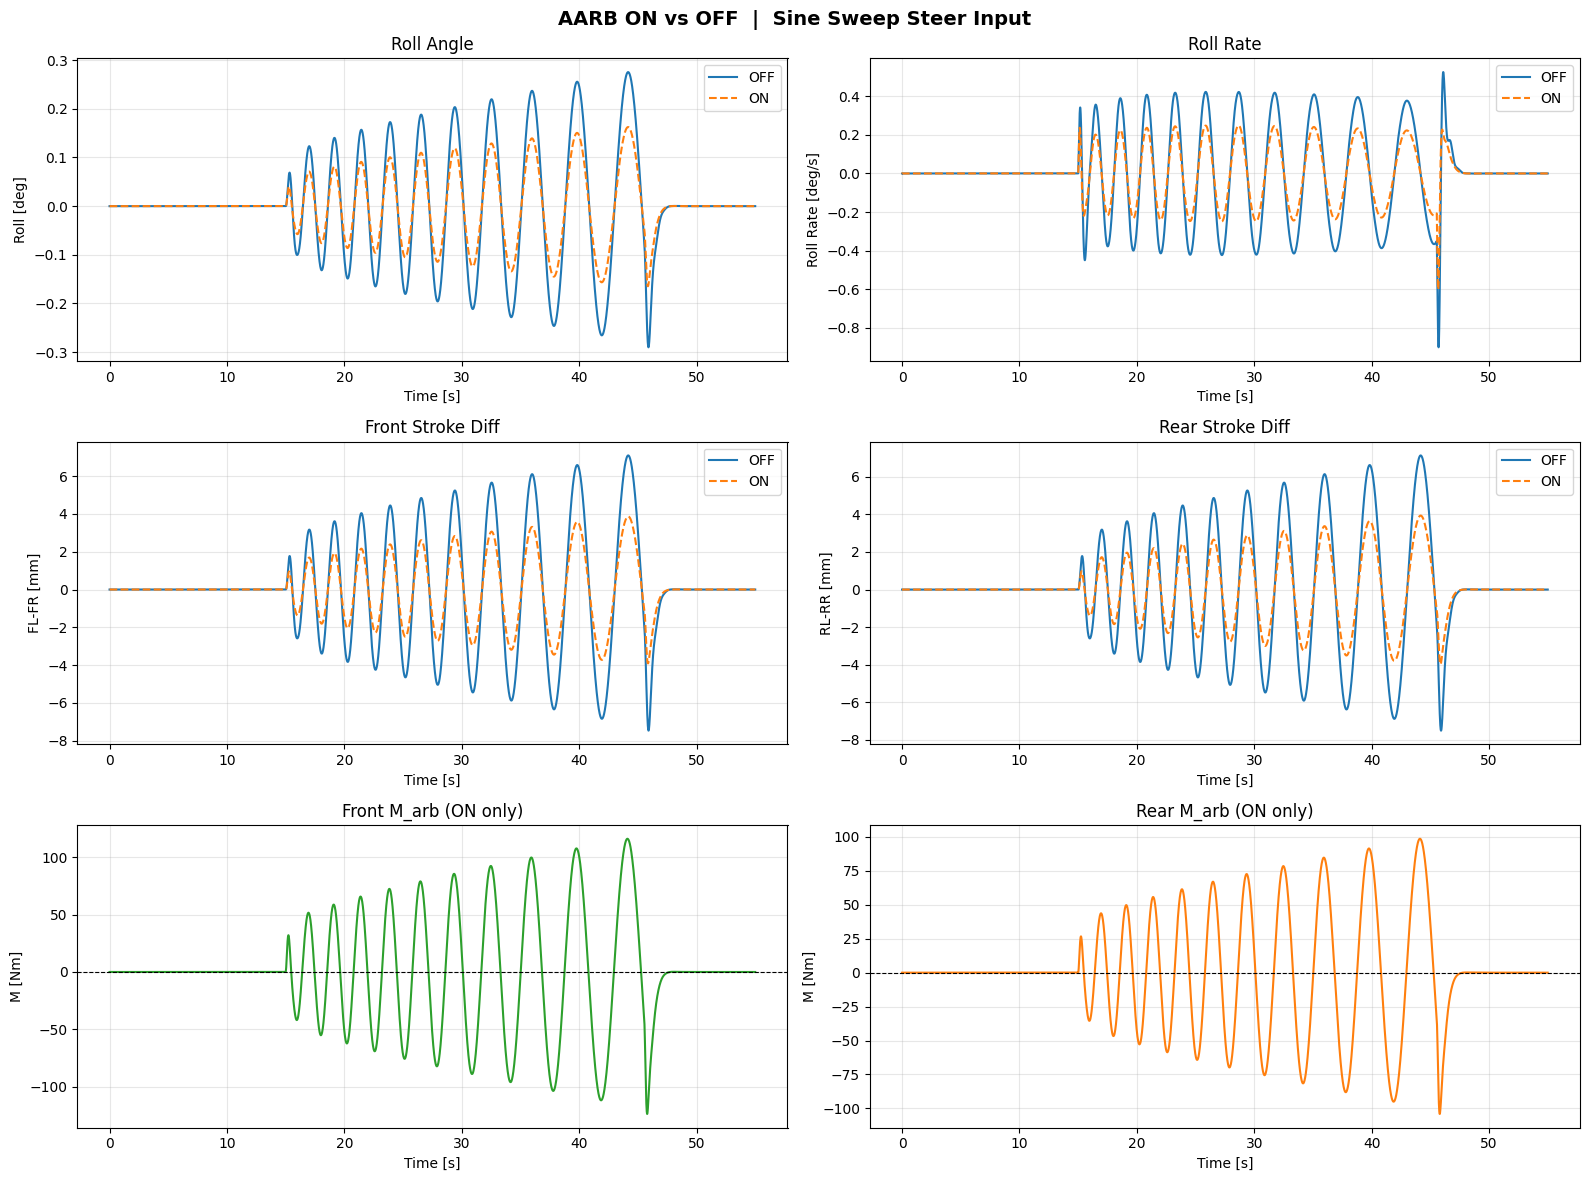

In [7]:
t   = scenario["time"]
off = result_off
on  = result_on

fig, ax = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("AARB ON vs OFF  |  Sine Sweep Steer Input", fontsize=14, fontweight="bold")

for a, y0, y1, yl, tl in [
    (ax[0,0], np.degrees(off["roll"]),          np.degrees(on["roll"]),          "Roll [deg]",        "Roll Angle"),
    (ax[0,1], np.degrees(off["roll_rate"]),     np.degrees(on["roll_rate"]),     "Roll Rate [deg/s]", "Roll Rate"),
    (ax[1,0], off["stroke_diff_front"]*1e3,     on["stroke_diff_front"]*1e3,     "FL-FR [mm]",        "Front Stroke Diff"),
    (ax[1,1], off["stroke_diff_rear"]*1e3,      on["stroke_diff_rear"]*1e3,      "RL-RR [mm]",        "Rear Stroke Diff"),
]:
    a.plot(t, y0, label="OFF", lw=1.5)
    a.plot(t, y1, label="ON",  lw=1.5, ls="--")
    a.set_xlabel("Time [s]"); a.set_ylabel(yl); a.set_title(tl)
    a.legend(); a.grid(alpha=0.3)

for a, key, col, tl in [
    (ax[2,0], "M_arb_front", "tab:green",  "Front M_arb (ON only)"),
    (ax[2,1], "M_arb_rear",  "tab:orange", "Rear M_arb (ON only)"),
]:
    a.plot(t, on[key], color=col, lw=1.5)
    a.set_xlabel("Time [s]"); a.set_ylabel("M [Nm]"); a.set_title(tl)
    a.axhline(0, color="k", ls="--", lw=0.8); a.grid(alpha=0.3)

fig.tight_layout()
plt.show()